In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fetching the Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# ! cp /content/drive/MyDrive/PKG/dataset.zip Dataset.zip

In [ ]:
!pip install gdown -q
!gdown 1ZjksHl2TNdClH5v3E5T5DrQgr_M1hfMo
!gdown 170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U

Downloading...
From: https://drive.google.com/uc?id=1ZjksHl2TNdClH5v3E5T5DrQgr_M1hfMo
To: /content/model.pkl
100% 3.17M/3.17M [00:00<00:00, 67.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U
From (redirected): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U&confirm=t&uuid=5d2eee27-8f64-4a4f-bd4a-78057ab98000
To: /content/dataset.zip
100% 276M/276M [00:05<00:00, 52.7MB/s]


In [ ]:
! unzip -q dataset.zip

# Importing Dependencies

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)
import joblib
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import joblib
# Visualization
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Constants

In [ ]:
BATCH_SIZE = 512
IMAGE_SIZE = 144
CHANNELS = 3
PATH = 'dataset/'

In [ ]:
def save_model(model):
  joblib.dump(model, 'model .pkl')
  print("Model Saved Successfully!")

# Importing data into a TensorFlow dataset object

We will use the `image_dataset_from_directory` API to load all images into a TensorFlow dataset. [Link to the documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory)

In [ ]:
train_ds = image_dataset_from_directory(
    PATH + '/train',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    PATH + '/test',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 56704 files belonging to 5 classes.
Found 24510 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names
class_names

['CBFB_MYH11', 'NPM1', 'Normal', 'PML_RARA', 'RUNX1_RUNX1T1']

# Visualizing the first batch of images.

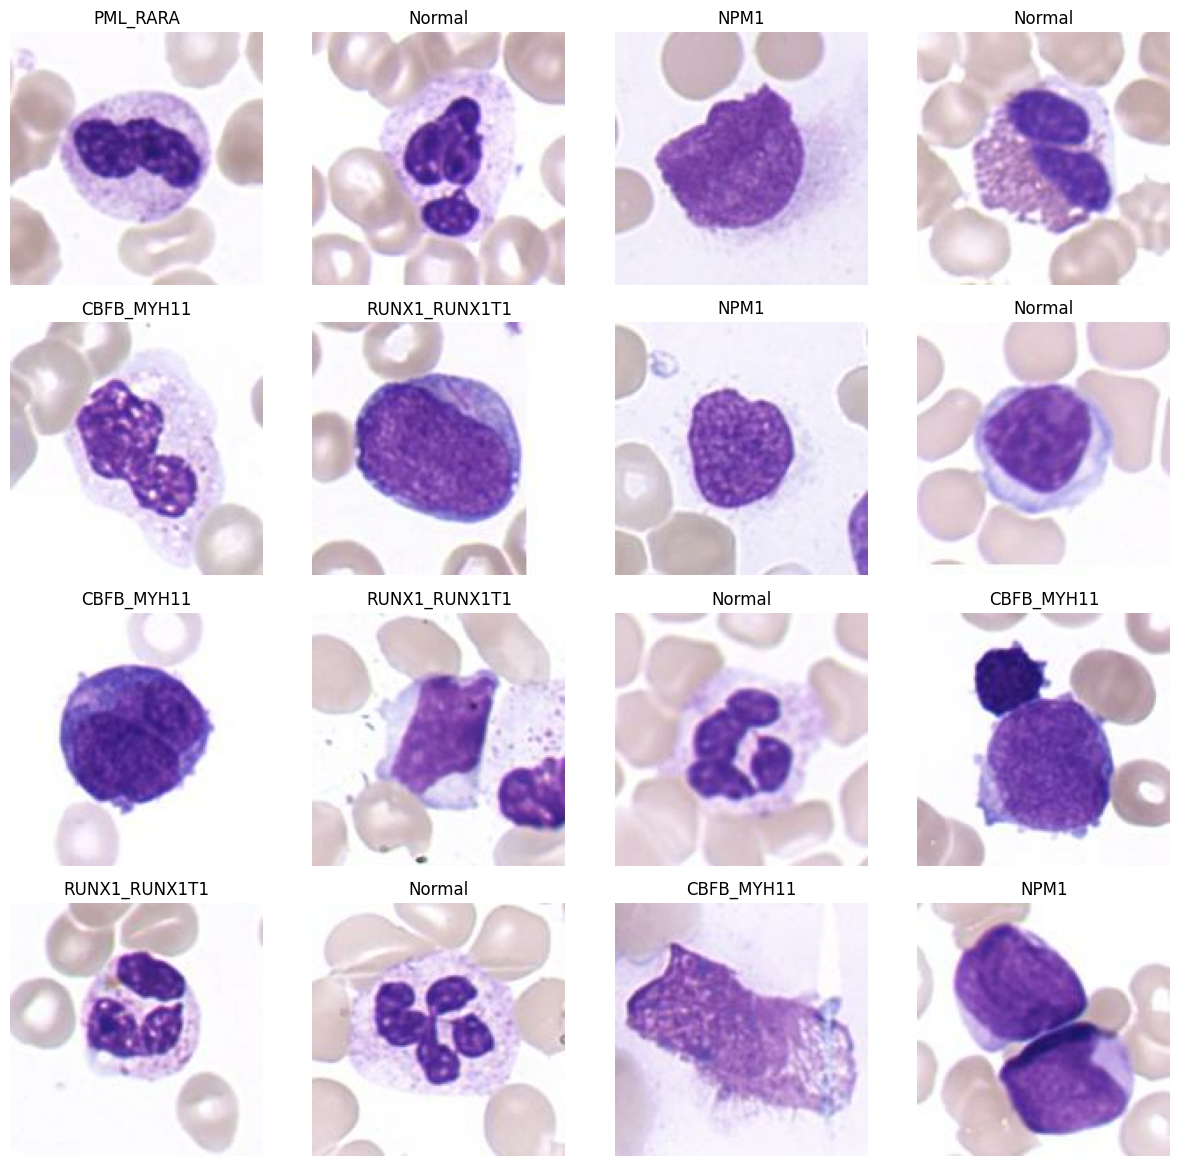

In [ ]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


In [ ]:
# train_batch = int(len(train_ds) * TRAIN_SIZE)
# train_data = train_ds.take(train_batch)

# Loading Models

In [ ]:
model1 = load_model('/content/drive/MyDrive/Final/Hybrid/Models/resnet.keras') # ResNet50
model2 = load_model('/content/drive/MyDrive/Final/Hybrid/Models/vit.keras') # ViT

In [ ]:
model1.summary()
model2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 144, 144, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 150, 150, 3)    │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 72, 72, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 72, 72, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 72, 72, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 74, 74, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 36, 36, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 36, 36, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 36, 36, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 36, 36, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 36, 36, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 24,376,465 (92.99 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 144, 144, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 150, 150, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 72, 72, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 72, 72, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 72, 72, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 74, 74, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 36, 36, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 36, 36, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 36, 36, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 36, 36, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 36, 36, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 24,376,465 (92.99 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 525,836 (2.01 MB)

# Create DataFrame

In [ ]:
train_predictions = []
train_labels = []
for images, labels in tqdm(train_ds):
    predictions1 = model1.predict(images, verbose = 0)
    predictions2 = model2.predict(images, verbose = 0)
    predictions = [predictions1.tolist()[i] + predictions2.tolist()[i] for i in range(len(predictions1))]
    train_predictions.extend(predictions)
    train_labels.extend(labels.numpy())

100%|██████████| 111/111 [05:21<00:00,  2.90s/it]


In [ ]:
test_predictions = []
test_labels = []
for images, labels in tqdm(test_ds):
    predictions1 = model1.predict(images, verbose = 0)
    predictions2 = model2.predict(images, verbose = 0)
    predictions = [predictions1.tolist()[i] + predictions2.tolist()[i] for i in range(len(predictions1))]
    test_predictions.extend(predictions)
    test_labels.extend(labels.numpy())

100%|██████████| 48/48 [02:21<00:00,  2.96s/it]


In [ ]:
train_df = pd.DataFrame(train_predictions)
test_df = pd.DataFrame(test_predictions)
train_df

,0,1,2,3,4,5,6,7,8,9
0,0.554815,0.169033,0.009368,0.087081,0.179704,4.764116e-01,4.475403e-01,8.253537e-04,5.631014e-03,6.959175e-02
1,0.709743,0.055354,0.027332,0.004095,0.203475,9.999450e-01,8.909313e-09,2.327735e-06,9.153450e-11,5.254676e-05
2,0.004236,0.004087,0.000034,0.991144,0.000498,1.363768e-14,1.128361e-10,1.512459e-07,9.996200e-01,3.799135e-04
3,0.222112,0.203443,0.063784,0.251938,0.258723,7.471519e-01,2.215132e-01,3.416832e-04,1.191960e-06,3.099204e-02
4,0.810342,0.130633,0.000219,0.028120,0.030687,9.999067e-01,2.825066e-05,7.505369e-09,6.410843e-05,9.378796e-07
...,...,...,...,...,...,...,...,...,...,...
56699,0.006432,0.007659,0.968729,0.006224,0.010956,1.385019e-04,3.609229e-04,9.994856e-01,1.475713e-05,1.442926e-07
56700,0.080119,0.105212,0.022515,0.644210,0.147944,1.174500e-02,3.517080e-02,9.524712e-03,2.370843e-01,7.064751e-01
56701,0.058874,0.028807,0.416785,0.391019,0.104514,7.392748e-02,2.024232e-03,9.239488e-01,8.379999e-06,9.110541e-05
56702,0.262117,0.617010,0.014894,0.031402,0.074577,9.988750e-01,5.059038e-04,9.215560e-08,4.630904e-05,5.726247e-04


# Model Training

In [ ]:
!pip install catboost -q
from catboost import CatBoostClassifier

In [ ]:
clf = CatBoostClassifier(iterations=1000,
                           task_type="GPU",
                           devices='0')

clf.fit(train_df, train_labels)

Learning rate set to 0.147918
0:	learn: 1.3975381	total: 12.1ms	remaining: 12.1s
1:	learn: 1.2713506	total: 25ms	remaining: 12.5s
2:	learn: 1.1878694	total: 43.7ms	remaining: 14.5s
3:	learn: 1.1284763	total: 54ms	remaining: 13.4s
4:	learn: 1.0802218	total: 65ms	remaining: 12.9s
5:	learn: 1.0424650	total: 79ms	remaining: 13.1s
6:	learn: 1.0112046	total: 90.2ms	remaining: 12.8s
7:	learn: 0.9864868	total: 101ms	remaining: 12.5s
8:	learn: 0.9665642	total: 112ms	remaining: 12.3s
9:	learn: 0.9502504	total: 124ms	remaining: 12.3s
10:	learn: 0.9362439	total: 135ms	remaining: 12.2s
11:	learn: 0.9254008	total: 145ms	remaining: 12s
12:	learn: 0.9160459	total: 156ms	remaining: 11.9s
13:	learn: 0.9074182	total: 167ms	remaining: 11.8s
14:	learn: 0.9010125	total: 179ms	remaining: 11.8s
15:	learn: 0.8960810	total: 192ms	remaining: 11.8s
16:	learn: 0.8910323	total: 203ms	remaining: 11.8s
17:	learn: 0.8868000	total: 215ms	remaining: 11.7s
18:	learn: 0.8830389	total: 225ms	remaining: 11.6s
19:	learn: 0.8

In [ ]:
save_model(clf)

Model Saved Successfully!


# Evaluation

## Loading Model

In [ ]:
model = joblib.load('model.pkl')

In [ ]:
pd.DataFrame(test_predictions)

,0,1,2,3,4,5,6,7,8,9
0,0.160363,0.500986,0.006980,0.106672,0.224998,9.939463e-01,5.791784e-03,3.360924e-08,6.244904e-06,2.556630e-04
1,0.001094,0.021724,0.973696,0.002777,0.000708,5.873903e-11,1.017914e-07,9.999999e-01,1.601184e-11,6.692206e-15
2,0.162647,0.360783,0.006853,0.211633,0.258083,3.953252e-04,3.275430e-04,1.066762e-05,2.884529e-03,9.963819e-01
3,0.077154,0.690391,0.004796,0.017222,0.210437,1.429953e-05,9.999789e-01,5.895720e-12,2.883512e-12,6.741792e-06
4,0.235461,0.053057,0.002683,0.346010,0.362789,3.920644e-04,6.401163e-06,1.198598e-14,2.710237e-06,9.995988e-01
...,...,...,...,...,...,...,...,...,...,...
24505,0.044596,0.168819,0.002263,0.055957,0.728364,4.843009e-04,6.934228e-08,3.128011e-12,9.995155e-01,1.545377e-07
24506,0.011721,0.151344,0.579173,0.229748,0.028014,5.059979e-05,9.862381e-01,1.357123e-02,1.401354e-04,1.667044e-08
24507,0.000839,0.000560,0.995625,0.002039,0.000937,1.348631e-06,2.508540e-08,9.999986e-01,1.428651e-13,9.486619e-11
24508,0.001416,0.003240,0.986753,0.003302,0.005288,1.967043e-05,7.444914e-08,9.999802e-01,4.775104e-13,2.594126e-16


# Evaluation

### Metrices

In [ ]:
y_classfication = model.predict(test_df)
y_test = test_labels

In [ ]:
accuracy = accuracy_score(y_test, y_classfication)
f1 = f1_score(y_test, y_classfication, average='weighted')
recall = recall_score(y_test, y_classfication, average='weighted')
precision = precision_score(y_test, y_classfication, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.9287229702162383
F1 Score:  0.9284851690505438
Recall:  0.9287229702162383
Precision:  0.9285331756560964


### Confusion Matrix

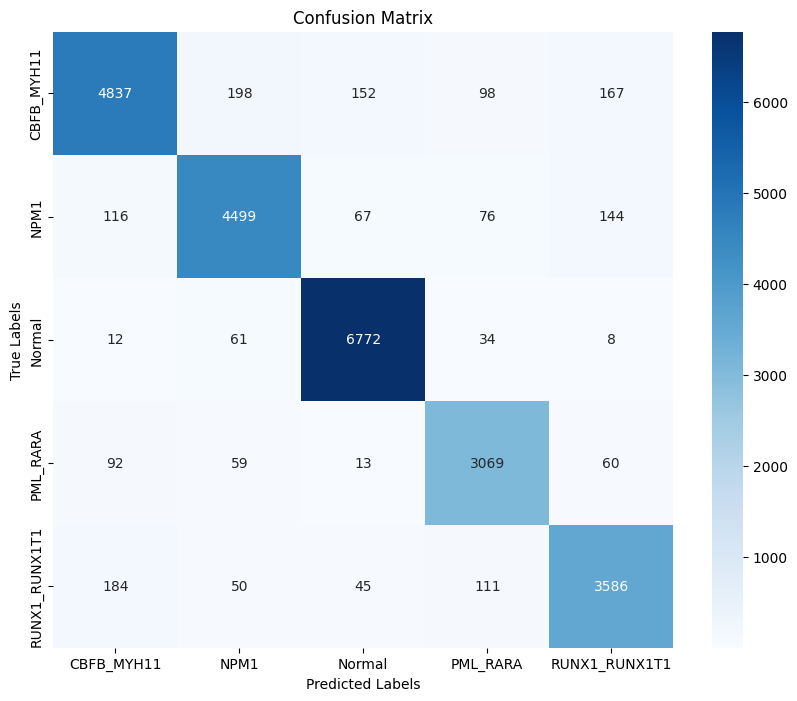

In [ ]:
conf_matrix = confusion_matrix(y_test, y_classfication)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', dpi = 300)
plt.show()


# Inference



## Inference Function

In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    prediction1 = model1.predict(img_array, verbose = 0).tolist()[0]
    prediction2 = model2.predict(img_array, verbose = 0).tolist()[0]
    return model.predict(prediction1 + prediction2)[0], 1.0

## Running Inference

<Figure size 640x480 with 0 Axes>

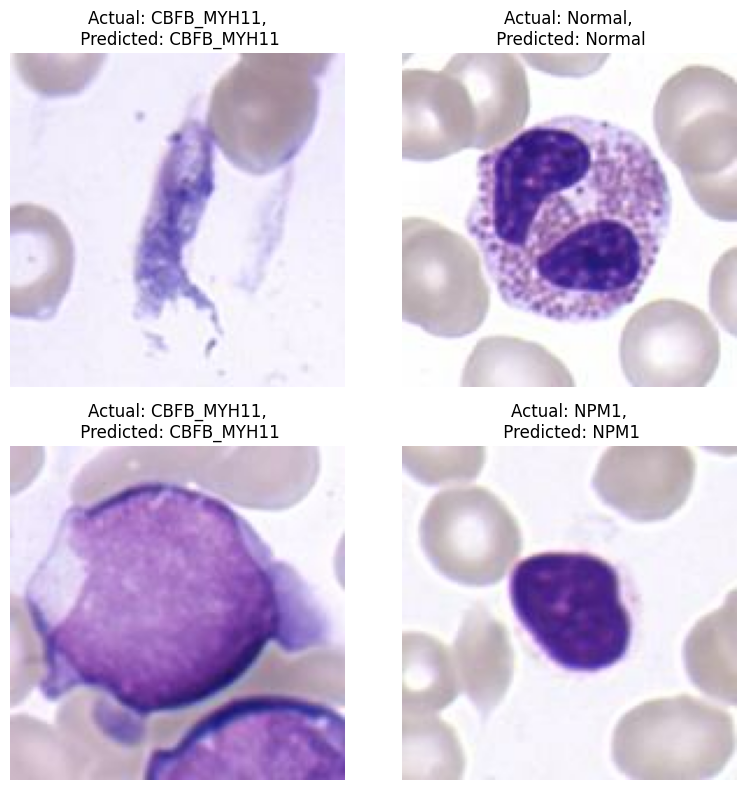

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in test_ds.take(6):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {class_names[predicted_class]}")
            ax.axis("off")
plt.tight_layout()
plt.show()


graph TD
    A[Load Images from Directory] --> B{Split into Train and Test Datasets}
    B --> C[Train Dataset]
    B --> D[Test Dataset]
    C --> E[ResNet50 Model]
    C --> F[ViT Model]
    D --> G[ResNet50 Model]
    D --> H[ViT Model]
    E --> I{Get Predictions}
    F --> I
    G --> J{Get Predictions}
    H --> J
    I --> K{Concatenate Predictions}
    J --> L{Concatenate Predictions}
    K --> M[CatBoost Classifier Training]
    L --> N[CatBoost Classifier Evaluation]
    M --> O[Trained CatBoost Model]
    O --> N
    N --> P[Evaluation Metrics and Confusion Matrix]